**1. 讀取各個需求與答案**

In [1]:
import json

test_gold = []
for i in range(1, 101):
    filename = f"../data/processed/test_gold/{i:03}.json"
    with open(filename, "r", encoding="utf-8") as f:
        test_gold.append(json.load(f))
print(test_gold)

[{'user_book_needs': '使用者的目標是學習商業微積分相關的基礎概念，並且他已具備一些微積分的基礎知識，沒有特定的應用領域', 'books': [{'id': '990052691730107976', 'title': '商用微積分 = Calculus for business'}, {'id': '990051193990107976', 'title': '商用微積分'}, {'id': '990060401900107976', 'title': '商用微積分'}, {'id': '990052968700107976', 'title': '商用微積分 = Brief calculus'}, {'id': '990052361310107976', 'title': '商用微積分 = Brief applied calculus'}, {'id': '990060238820107976', 'title': '現代商用微積分 = Modern commercial calculus'}, {'id': '990052069630107976', 'title': '現代商用微積分'}, {'id': '990060053120107976', 'title': '商用微積分 = Calculus for business'}, {'id': '990052567890107976', 'title': '商用微積分 = Adapted From Calculus'}, {'id': '990052684510107976', 'title': '商用微積分(第九版) = Applied calculus for business, economics, and the social and life science'}]}, {'user_book_needs': '使用者的目標是學習有關電腦病毒的基礎知識，包括歷史、類型和防治方法，並且他們的技術水平為初學者', 'books': [{'id': '990051186810107976', 'title': 'Easy to know電腦病毒'}, {'id': '990050146620107976', 'title': '解毒大師 : SCAN 與 PRO-SCAN 使用圖例入

**2. 根據各個需求生成答案 [Baseline]**

In [2]:
import os
import json
import requests
from dotenv import load_dotenv
load_dotenv()

ES_API_URL = os.getenv("ES_API_URL")
ES_API_KEY = os.getenv("ES_API_KEY")
header = {
    "Authorization": f"Apikey {ES_API_KEY}",
    "Content-Type": "application/json"
}
result_baseline = []
for i, data in enumerate(test_gold):
    result = {"user_book_needs": data["user_book_needs"], "books": []}
    post_data = {
        "query": {
            "simple_query_string": {
                "query": result["user_book_needs"]
            }
        }
    }
    response = requests.get(f"{ES_API_URL}/books/_search?size=10", headers=header, json=post_data)
    print(response.json())
    for book in response.json()["hits"]["hits"]:
        result["books"].append({
            "id": book["_source"]["id"],
            "title": book["_source"]["title"]
        })
    result_baseline.append(result)
    # save result to file
    filename = f"../data/processed/test_baseline/{i+1:03}.json"
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(result, f, indent=2, ensure_ascii=False)
    print(f"Saved result to {filename}")
print(json.dumps(result_baseline, indent=2, ensure_ascii=False))

{'took': 3, 'timed_out': False, '_shards': {'total': 1, 'successful': 1, 'skipped': 0, 'failed': 0}, 'hits': {'total': {'value': 9472, 'relation': 'eq'}, 'max_score': 40.99634, 'hits': [{'_index': 'books', '_id': '990051908290107976', '_score': 40.99634, '_source': {'id': '990051908290107976', 'title': '基礎微積分'}}, {'_index': 'books', '_id': '990051291210107976', '_score': 39.104176, '_source': {'id': '990051291210107976', 'title': '基礎微積分精要'}}, {'_index': 'books', '_id': '990052488760107976', '_score': 37.378967, '_source': {'id': '990052488760107976', 'title': '隨機微積分基礎'}}, {'_index': 'books', '_id': '990050805720107976', '_score': 35.799553, '_source': {'id': '990050805720107976', 'title': '分析基礎課程 : 微積分'}}, {'_index': 'books', '_id': '990052355250107976', '_score': 35.749958, '_source': {'id': '990052355250107976', 'title': '基礎分析學之一 : 單元微積分學'}}, {'_index': 'books', '_id': '990052355210107976', '_score': 33.75782, '_source': {'id': '990052355210107976', 'title': '基礎分析學之二 : 多元微積分學'}}, {'_

**3. 根據各個需求生成答案 [Smart Book Seeker]**

In [ ]:
from smart_book_seeker import ConversationManager

result_sbs = []
for i, data in enumerate(test_gold):
    # if i < 78:  # Skip the first 17 test cases
    #     continue
    result = {"user_book_needs": data["user_book_needs"], "books": []}
    cm = ConversationManager(strategy="iterative_top_k")
    for response in cm.discuss(book_search_needs=result["user_book_needs"]):
        print(f"\033[96m✦\033[0m {response}")
    for book in cm.user_agent.environment.current_books:
        result["books"].append({
            "id": book.id,
            "title": book.title
        })
    result_sbs.append(result)
    # save result to file
    filename = f"../data/processed/test_sbs/{i+1:03}.json"
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(result, f, indent=2, ensure_ascii=False)
    print(f"Saved result to {filename}")
print(json.dumps(result_sbs, indent=2, ensure_ascii=False))

**4. 計算成績**

In [8]:
import json

score_baseline = []
score_sbs = []

result_baseline = []
result_sbs = []

# load from json files
for i in range(1, 101):
    filename_baseline = f"../data/processed/test_baseline/{i:03}.json"
    filename_sbs = f"../data/processed/test_sbs/{i:03}.json"
    with open(filename_baseline, "r", encoding="utf-8") as f:
        result_baseline.append(json.load(f))
    with open(filename_sbs, "r", encoding="utf-8") as f:
        result_sbs.append(json.load(f))

for i, data in enumerate(test_gold):
    data["baseline_books"] = result_baseline[i]["books"]
    data["sbs_books"] = result_sbs[i]["books"]
    score = {"baseline": 0, "sbs": 0}
    for book in data["baseline_books"]:
        for ans_book in data["books"]:
            if book["id"] == ans_book["id"]:
                score["baseline"] += 1
    score["baseline"] *= 10
    for book in data["sbs_books"]:
        for ans_book in data["books"]:
            if book["id"] == ans_book["id"]:
                score["sbs"] += 1
    score["sbs"] *= 10
    score_baseline.append(score["baseline"])
    score_sbs.append(score["sbs"])
    print(f"[{data["user_book_needs"]}] Baseline: {score["baseline"]:.2f}, SBS: {score["sbs"]:.2f}")
print(score_baseline)
print(score_sbs)

# Average
avg_baseline = sum(score_baseline) / len(score_baseline)
avg_sbs = sum(score_sbs) / len(score_sbs)
print(f"Average Baseline: {avg_baseline:.2f}, Average SBS: {avg_sbs:.2f}")

# Variance
import numpy as np
var_baseline = np.var(score_baseline)
var_sbs = np.var(score_sbs)
print(f"Variance Baseline: {var_baseline:.2f}, Variance SBS: {var_sbs:.2f}")

# 中位數
median_baseline = np.median(score_baseline)
median_sbs = np.median(score_sbs)
print(f"Median Baseline: {median_baseline:.2f}, Median SBS: {median_sbs:.2f}")

# 標準差
std_baseline = np.std(score_baseline)
std_sbs = np.std(score_sbs)
print(f"Standard Deviation Baseline: {std_baseline:.2f}, Standard Deviation SBS: {std_sbs:.2f}")


[使用者的目標是學習商業微積分相關的基礎概念，並且他已具備一些微積分的基礎知識，沒有特定的應用領域] Baseline: 0.00, SBS: 0.00
[使用者的目標是學習有關電腦病毒的基礎知識，包括歷史、類型和防治方法，並且他們的技術水平為初學者] Baseline: 30.00, SBS: 0.00
[使用者的目標是尋找有關量子物理相關的基礎知識，偏好通俗易懂的介紹，並且希望是適合初學者的書籍] Baseline: 10.00, SBS: 0.00
[使用者想找入門電子學的書，重點在基本原理與概念，內容簡單易懂、適合初學者] Baseline: 10.00, SBS: 20.00
[使用者的目標是尋找簡單易懂的書籍，以學習有關不同自然生態或是動物生態的基礎知識] Baseline: 20.00, SBS: 0.00
[使用者的目標是尋找有關使用威力導演11版本以上的工具來對影音進行剪輯以及創作等等應用的書籍] Baseline: 80.00, SBS: 90.00
[使用者的目標是尋找有關介紹科學家費曼生平的故事，偏好以輕鬆有趣的說法來述說故事的書籍] Baseline: 30.00, SBS: 10.00
[使用者的目標是尋找有關學習太陽能電池的原理、技術、材料和一些基礎應用的書籍] Baseline: 60.00, SBS: 50.00
[使用者的目標是尋找有關昆蟲的圖鑑以及相關有趣知識及各方各面知識的書籍] Baseline: 10.00, SBS: 30.00
[使用者的目標是尋找有關怎麼使用tensorflow來學習實作有關深度學習的開發相關知識的書籍] Baseline: 30.00, SBS: 80.00
[使用者的目標是尋找有關怎麼使用Flash CS3來進行網頁動畫的製作、創作和相關應用的書籍] Baseline: 30.00, SBS: 50.00
[使用者的目標是尋找有關怎麼使用Flash CS4來進行網頁動畫的製作、創作和相關應用的書籍] Baseline: 20.00, SBS: 10.00
[使用者的目標是尋找有關怎麼使用Flash CS5來進行網頁動畫的製作、創作和相關應用的書籍] Baseline: 0.00, SBS: 10.00
[使用者的目標是尋找2020~2024年使用AutoCAD來進行電腦繪圖方法或是教材的書籍] B

**5. 畫圖**

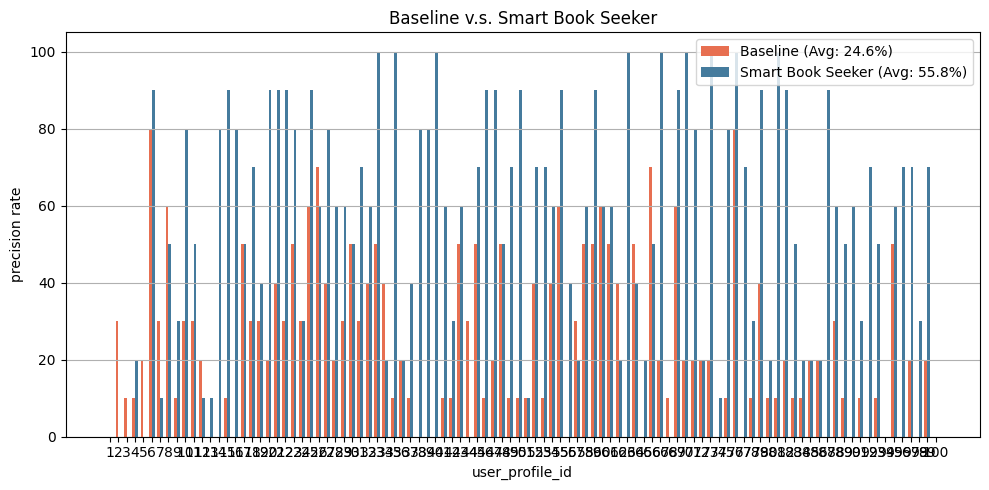

In [6]:
import matplotlib.pyplot as plt

# 資料
base = score_baseline
my =   score_sbs
x = list(range(1, len(base) + 1))

# 計算平均值
base_mean = sum(base) / len(base)
my_mean = sum(my) / len(my)

# 繪圖（改為長條圖）
plt.figure(figsize=(10, 5))
bar_width = 0.35
plt.bar([i - bar_width/2 for i in x], base, width=bar_width, label=f'Baseline (Avg: {base_mean:.1f}%)', color='#E76F51')
plt.bar([i + bar_width/2 for i in x], my, width=bar_width, label=f'Smart Book Seeker (Avg: {my_mean:.1f}%)', color='#457B9D')

plt.xlabel('user_profile_id')
plt.ylabel('precision rate')
plt.title('Baseline v.s. Smart Book Seeker')

plt.legend(loc='upper right')
plt.grid(axis='y')
plt.tight_layout()
plt.xticks(x)

plt.show()

In [23]:
import numpy as np                     # <─ 新增：算平均用
import matplotlib.pyplot as plt
from matplotlib.patches import Patch   # <─ 新增：自訂圖例用

# Data：假設你已經有下面兩個 list/array
data1 = score_baseline
data2 = score_sbs
data   = [data1, data2]
labels = ['Baseline', 'Smart Book Seeker']
colors = ['#E76F51', '#457B9D']          # 每組顏色

# ---------- 計算平均 ----------
avg1 = np.mean(data1)
avg2 = np.mean(data2)

plt.figure(figsize=(6, 4), dpi=300)
box = plt.boxplot(data, patch_artist=True)

# 逐盒填色
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.xticks([1, 2], labels)               # 注意 index 從 1 開始
plt.title('Baseline v.s. Smart Book Seeker')
plt.ylabel('Precision Rate (%)')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# ---------- 自訂 Legend ----------
legend_elements = [
    Patch(facecolor=colors[0], label=f'Baseline (Average = {avg1:.2f}%)'),
    Patch(facecolor=colors[1], label=f'Smart Book Seeker (Average = {avg2:.2f}%)')
]
plt.legend(handles=legend_elements, loc='upper left')

# 儲存或顯示圖
# plt.show()
plt.savefig('boxplot.pdf')
plt.close()

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ==== 資料 ====
data1 = score_baseline
data2 = score_sbs
data   = [data1, data2]
labels = ['Baseline', 'SBS-AARS']

# ==== 計算平均 ====
avg1 = np.mean(data1)
avg2 = np.mean(data2)

plt.figure(figsize=(6, 4), dpi=300)

box = plt.boxplot(
    data,
    patch_artist=True,
    boxprops=dict(color='black'),
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)

# ==== 設定紋路 ====
hatches = ['', '///']          # Baseline 無紋；SBS 斜線
for patch, hatch in zip(box['boxes'], hatches):
    patch.set_facecolor('white')
    patch.set_hatch(hatch)
    patch.set_edgecolor('black')

plt.xticks([1, 2], labels)
# plt.title('Baseline v.s. SBS-AARS')
plt.ylabel('Precision Rate (%)')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# ==== Legend ====
# legend_elements = [
#     Patch(facecolor='white', edgecolor='black', hatch=hatches[0],
#           label=f'Baseline (Average = {avg1:.2f}%)'),
#     Patch(facecolor='white', edgecolor='black', hatch=hatches[1],
#           label=f'Smart Book Seeker (Average = {avg2:.2f}%)')
# ]
# plt.legend(handles=legend_elements, loc='upper left')

# 儲存或顯示圖
# plt.show()
plt.savefig('boxplot_bw.pdf')
plt.close()